In [282]:
import pandas as pd

df =pd.read_parquet("data.parquet")

# divise le jeu pour comparaison
df_demission = df[df["a_quitte_l_entreprise"] == True]
df_en_place = df[df["a_quitte_l_entreprise"] == False]

df.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,domaine_etude,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,age,...,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente_percent,est_un_homme
0,True,0,0,1,2,Infra & Cloud,1,0,5,41,...,2,3,2,4,1,1,3,True,11,False
1,False,1,3,8,1,Infra & Cloud,2,1,7,49,...,3,2,2,2,4,3,4,False,23,True
2,True,0,3,2,2,Autre,1,0,0,37,...,4,2,1,3,2,3,3,True,15,True
3,False,0,3,3,4,Infra & Cloud,2,3,0,33,...,4,3,1,3,3,3,3,True,11,False
4,False,1,3,2,1,Transformation Digitale,1,2,2,27,...,1,3,1,2,4,3,3,False,12,True


In [283]:
pd.DataFrame(df.columns)

,0
0,a_quitte_l_entreprise
1,nombre_participation_pee
2,nb_formations_suivies
3,distance_domicile_travail
4,niveau_education
5,domaine_etude
6,frequence_deplacement
7,annees_depuis_la_derniere_promotion
8,annes_sous_responsable_actuel
9,age


In [284]:

df.describe().T

,count,mean,std,min,25%,50%,75%,max
nombre_participation_pee,1470.0,0.793878,0.852077,0.0,0.0,1.0,1.0,3.0
nb_formations_suivies,1470.0,2.799320,1.289271,0.0,2.0,3.0,3.0,6.0
distance_domicile_travail,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
niveau_education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
frequence_deplacement,1470.0,1.086395,0.532170,0.0,1.0,1.0,1.0,2.0
annees_depuis_la_derniere_promotion,1470.0,2.187755,3.222430,0.0,0.0,1.0,3.0,15.0
annes_sous_responsable_actuel,1470.0,4.123129,3.568136,0.0,2.0,3.0,7.0,17.0
age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
revenu_mensuel,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
nombre_experiences_precedentes,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0


# Répartition homme / femme est t'elle équilibré ?

In [285]:
df["est_un_homme"].value_counts(normalize=True)

est_un_homme
True     0.6
False    0.4
Name: proportion, dtype: float64

# note_evaluation_actuelle

In [286]:
# Presque toutes les notes on 3 ou 4 (binaire déguisé)
df["note_evaluation_actuelle"].value_counts(normalize=True)

note_evaluation_actuelle
3    0.846259
4    0.153741
Name: proportion, dtype: float64

In [287]:
# les notes sont réparties équitablement entre départ/en place
df.groupby("a_quitte_l_entreprise")["note_evaluation_actuelle"].value_counts(normalize=True)

a_quitte_l_entreprise  note_evaluation_actuelle
False                  3                           0.846715
                       4                           0.153285
True                   3                           0.843882
                       4                           0.156118
Name: proportion, dtype: float64

In [288]:
# note_evaluation_actuelle ne joue quasiment aucun rôle dans le départ
df.groupby("note_evaluation_actuelle")["a_quitte_l_entreprise"].mean()

note_evaluation_actuelle
3    0.160772
4    0.163717
Name: a_quitte_l_entreprise, dtype: float64

# note_evaluation_precedente

In [289]:
# Les notes sont réparties inéquitablement
df["note_evaluation_precedente"].value_counts(normalize=True)

note_evaluation_precedente
3    0.590476
2    0.255102
4    0.097959
1    0.056463
Name: proportion, dtype: float64

In [290]:
# les notes sont distribuées assez équitablement entre les départ / resté
df.groupby("a_quitte_l_entreprise")["note_evaluation_precedente"].value_counts(normalize=True)

a_quitte_l_entreprise  note_evaluation_precedente
False                  3                             0.602595
                       2                             0.246553
                       4                             0.106245
                       1                             0.044607
True                   3                             0.527426
                       2                             0.299578
                       1                             0.118143
                       4                             0.054852
Name: proportion, dtype: float64

In [291]:
# par-contre les départs on donné une note proportionnellement moins bonne avant de partir
# résultat il y a une forte correlation: plus la note d’évaluation est basse, plus le risque de départ est élevé
df.groupby("note_evaluation_precedente")["a_quitte_l_entreprise"].mean()

note_evaluation_precedente
1    0.337349
2    0.189333
3    0.144009
4    0.090278
Name: a_quitte_l_entreprise, dtype: float64

In [292]:
df["salaire_bin"] = pd.qcut(df["revenu_mensuel"], 4)

pd.DataFrame(df.groupby([
    "poste",
    "frequence_deplacement",
    "salaire_bin",
    "note_evaluation_precedente"
])["a_quitte_l_entreprise"].mean())

a_quitte_l_entreprise
poste                  frequence_deplacement salaire_bin        note_evaluation_precedente                       
Assistant de Direction 0                     (1008.999, 2911.0] 1                                           0.500
                                                                2                                           0.500
                                                                3                                           0.000
                                                                4                                           0.000
                                             (2911.0, 4919.0]   2                                           0.000
...                                                                                                           ...
Tech Lead              2                     (4919.0, 8379.0]   4                                           0.200
                                             (8379.0, 19999.0]  1                                           1.000
                                                                2                                           0.000
                                                                3                                           0.125
                                                                4                                           0.000

[210 rows x 1 columns]

In [293]:

sat_cols = [
    "satisfaction_employee_environnement",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso"
]
df["satisfaction_moyenne"] = df[sat_cols].mean(axis=1)

df["satisfaction_moyenne"].value_counts()

satisfaction_moyenne
2.75    272
3.00    265
2.50    239
2.25    196
3.25    185
3.50    106
2.00     98
1.75     38
3.75     35
1.50     23
4.00      6
1.25      6
1.00      1
Name: count, dtype: int64

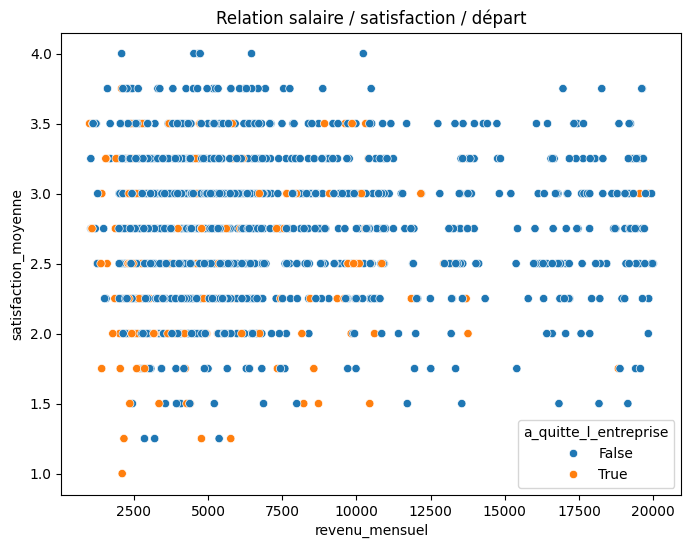

In [294]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="revenu_mensuel",
    y="satisfaction_moyenne",
    hue="a_quitte_l_entreprise"
)
plt.title("Relation salaire / satisfaction / départ")
plt.show()

# niveau_hierarchique_poste / poste

In [295]:
pd.crosstab(
    df["poste"],
    df["niveau_hierarchique_poste"],
    normalize="index"
).round(2)

niveau_hierarchique_poste,1,2,3,4,5
poste,,,,,
Assistant de Direction,0.80,0.20,0.00,0.00,0.00
Cadre Commercial,0.00,0.71,0.24,0.04,0.00
Consultant,0.77,0.22,0.01,0.00,0.00
Directeur Technique,0.00,0.00,0.35,0.32,0.32
Manager,0.00,0.60,0.34,0.07,0.00
Représentant Commercial,0.92,0.08,0.00,0.00,0.00
Ressources Humaines,0.63,0.25,0.12,0.00,0.00
Senior Manager,0.00,0.00,0.12,0.46,0.42
Tech Lead,0.00,0.62,0.31,0.07,0.00


Les niveaux hiérachique bas (1,2,3) sont représenté par: Représentant Commercial, Ressources Humaines, Consultant, Assistant de Direction

 # Revenus

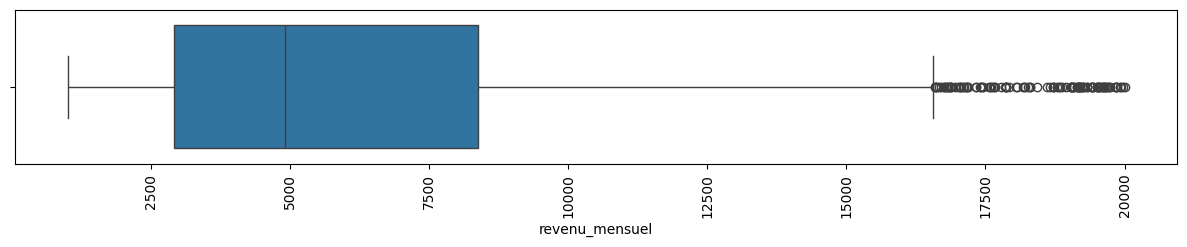

In [296]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 2))
sns.boxplot(x=df["revenu_mensuel"])
plt.xticks(rotation=90)
plt.show()

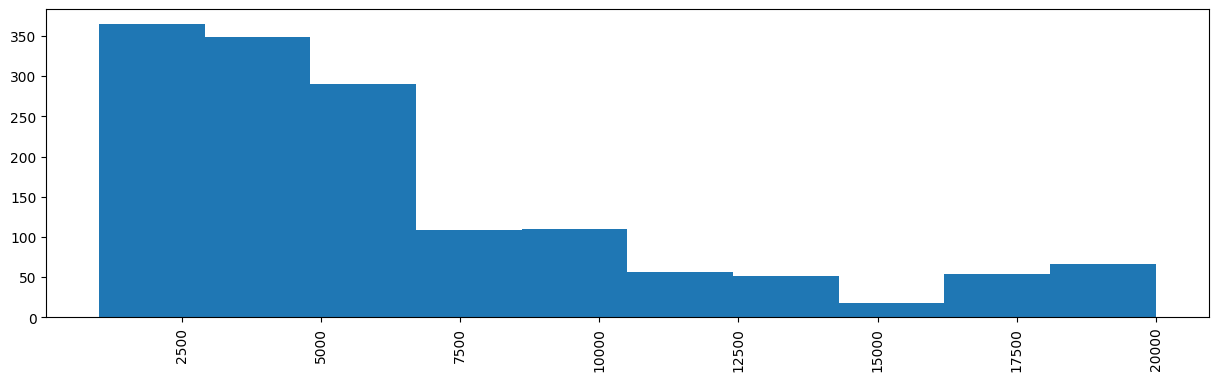

In [297]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.hist(x=df["revenu_mensuel"])
plt.xticks(rotation=90)
plt.show()

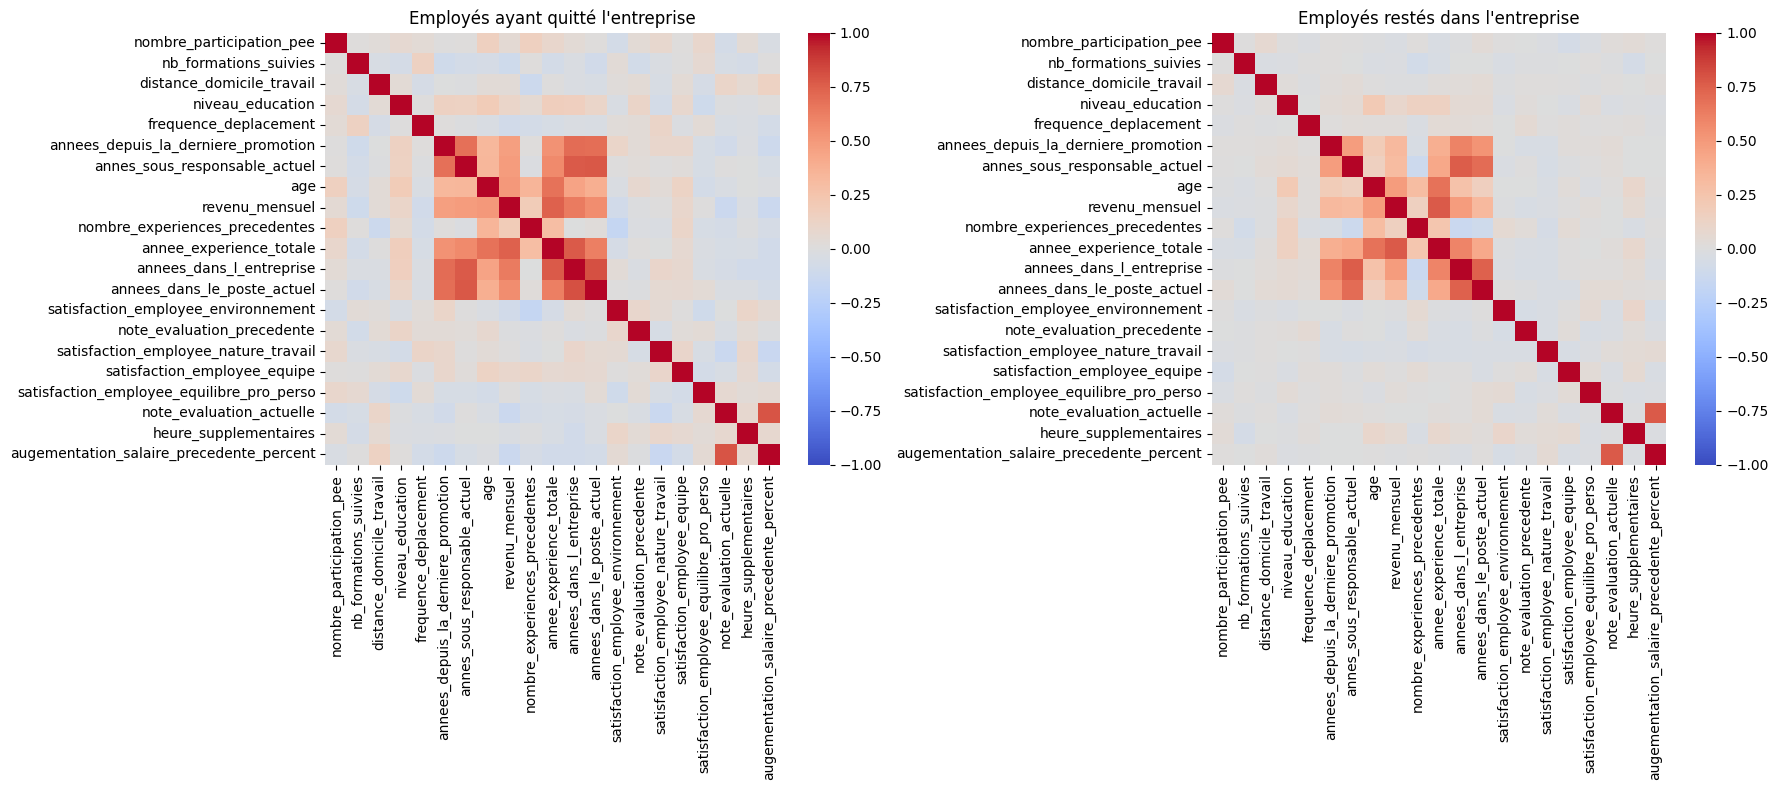

In [326]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_num = [
    "nombre_participation_pee",
    "nb_formations_suivies",
    "distance_domicile_travail",
    "niveau_education",
    "frequence_deplacement",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "satisfaction_employee_environnement",
    "note_evaluation_precedente",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_actuelle",
    "heure_supplementaires",
    "augementation_salaire_precedente_percent",
]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(
    df_demission[cols_num].corr(),
    annot=False,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0]
)
axes[0].set_title("Employés ayant quitté l'entreprise")

sns.heatmap(
    df_en_place[cols_num].corr(),
    annot=False,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[1]
)
axes[1].set_title("Employés restés dans l'entreprise")

plt.tight_layout()
plt.show()

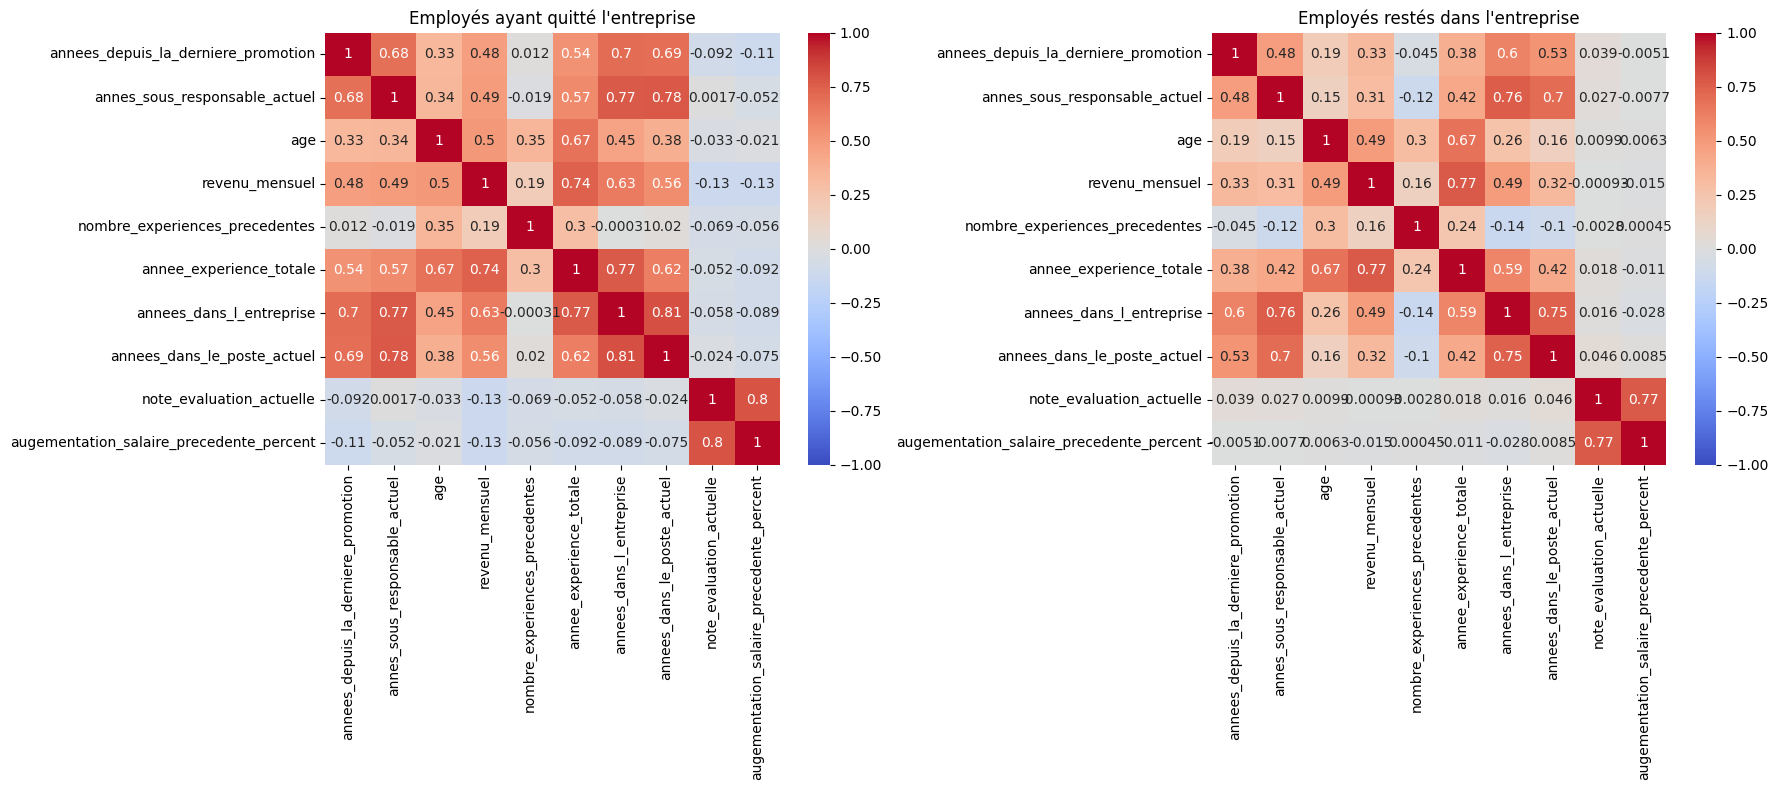

In [327]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_num = [
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "note_evaluation_actuelle",
    "augementation_salaire_precedente_percent",
]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(
    df_demission[cols_num].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0]
)
axes[0].set_title("Employés ayant quitté l'entreprise")

sns.heatmap(
    df_en_place[cols_num].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[1]
)
axes[1].set_title("Employés restés dans l'entreprise")

plt.tight_layout()
plt.show()

La comparaison des correlations ne révéle rien de très différent entre employé en place/démissionné 
hormi le salaire et la position hiérarchique

In [300]:
features = [
    "age",
    "nombre_participation_pee",
    "nb_formations_suivies",
    "niveau_education",
    "frequence_deplacement",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
    "nombre_experiences_precedentes",
    "annees_dans_le_poste_actuel",
    "note_evaluation_precedente",
    "note_evaluation_actuelle",
    "niveau_hierarchique_poste",
    "heure_supplementaires",
    "augementation_salaire_precedente_percent",
    "est_un_homme",
    "revenu_mensuel",
    "distance_domicile_travail",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_environnement",
]

comparaison = (
    df.groupby("a_quitte_l_entreprise")[features]
      .mean()
)

display(comparaison.T)

a_quitte_l_entreprise,False,True
age,37.561233,33.607595
nombre_participation_pee,0.845093,0.527426
nb_formations_suivies,2.832928,2.624473
niveau_education,2.927007,2.839662
frequence_deplacement,1.056772,1.240506
annees_depuis_la_derniere_promotion,2.234388,1.945148
annes_sous_responsable_actuel,4.367397,2.852321
nombre_experiences_precedentes,2.645580,2.940928
annees_dans_le_poste_actuel,4.484185,2.902954
note_evaluation_precedente,2.770479,2.518987



* Il n'y a pas plus ou moins de différences pour : la satisfaction, les formations, niveau, augementation salaire, HF, 
* Il y a une différence d'années dans l'entreprise qui peut s'expliquer par l'expérience (ancienneté)
* Il y a une différence de salaire qui peut s'expliquer par l'expérience (ancienneté)
* Il y a une différence de nombre de participations au PEE qui peut s'expliquer par l'expérience (ancienneté)
* Il y a une différence d'age qui peut s'expliquer par l'expérience (ancienneté)
* Il y a pas une forte différence avec les heures supplémentaires pour les démissions (+0.3h)
------------------------------------------------------------------------------------------------------------
* Il y a une différence avec la distance domicile/travail pour les démissions (+1.5 km)

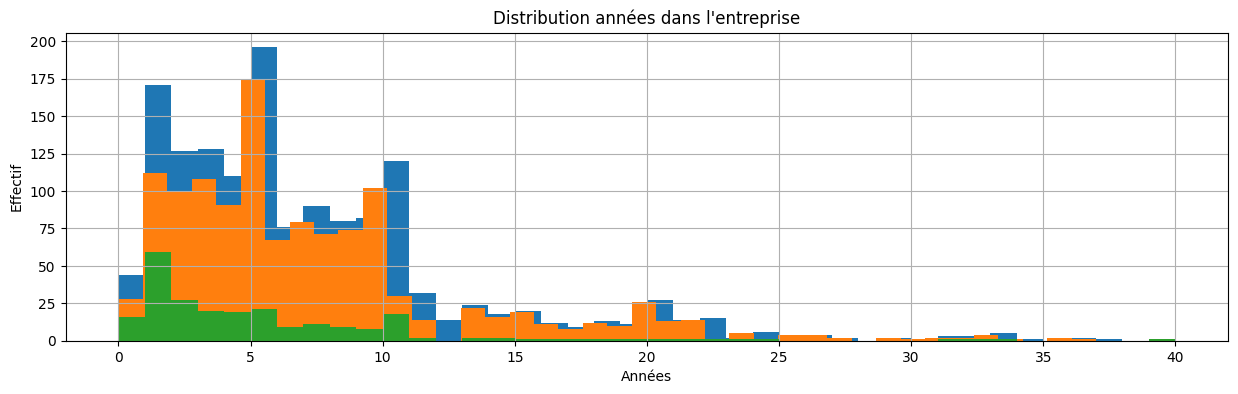

In [301]:

plt.figure(figsize=(15, 4))
df["annees_dans_l_entreprise"].hist(bins=40)
df_en_place["annees_dans_l_entreprise"].hist(bins=40)
df_demission["annees_dans_l_entreprise"].hist(bins=40)
plt.title("Distribution années dans l'entreprise")
plt.xlabel("Années")
plt.ylabel("Effectif")
plt.show()

Après 10 ans d'ancienneté il y a une forte chute des effectifs encore en place. 

On sépare le jeu en +10 ans et <= 10 ans pour vérifier les différences par rapport à l'ancienneté

In [302]:
df_anciens = df[df["annees_dans_l_entreprise"] > 10]
df_jeunes = df[df["annees_dans_l_entreprise"] <= 10]

In [303]:
stats = pd.DataFrame();

features = [
    "nombre_participation_pee",
    "nb_formations_suivies",
    "niveau_education",
    "frequence_deplacement",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
    "nombre_experiences_precedentes",
    "annees_dans_le_poste_actuel",
    "note_evaluation_precedente",
    "note_evaluation_actuelle",
    "niveau_hierarchique_poste",
    "heure_supplementaires",
    "augementation_salaire_precedente_percent",
    "est_un_homme",
    "revenu_mensuel",
    "distance_domicile_travail",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_environnement",
]


df1 = (
    df_anciens.groupby("a_quitte_l_entreprise")[features]
    .mean().round(2)
).T

df1.rename(columns={False: "False (+10)", True: "True (+10)"}, inplace=True)

df2 = (
    df_jeunes.groupby("a_quitte_l_entreprise")[features]
    .mean().round(2)
).T

df2.rename(columns={False: "False (-10)", True: "True (-10)"}, inplace=True)

display(pd.concat([df1, df2], axis=1))

a_quitte_l_entreprise,False (+10),True (+10),False (-10),True (-10)
nombre_participation_pee,0.81,0.45,0.85,0.53
nb_formations_suivies,2.82,2.55,2.84,2.63
niveau_education,3.00,3.20,2.91,2.81
frequence_deplacement,1.05,1.25,1.06,1.24
annees_depuis_la_derniere_promotion,5.87,8.05,1.42,1.38
annes_sous_responsable_actuel,9.26,8.25,3.27,2.35
nombre_experiences_precedentes,2.40,3.15,2.70,2.92
annees_dans_le_poste_actuel,9.48,8.95,3.36,2.35
note_evaluation_precedente,2.70,2.30,2.79,2.54
note_evaluation_actuelle,3.18,3.15,3.15,3.16


on note :

* Il y a une différence avec la distance domicile/travail pour les démissions (+1.5 km)

<Axes: xlabel='frequence_deplacement', ylabel='Taux de démission par déplacement (%)'>

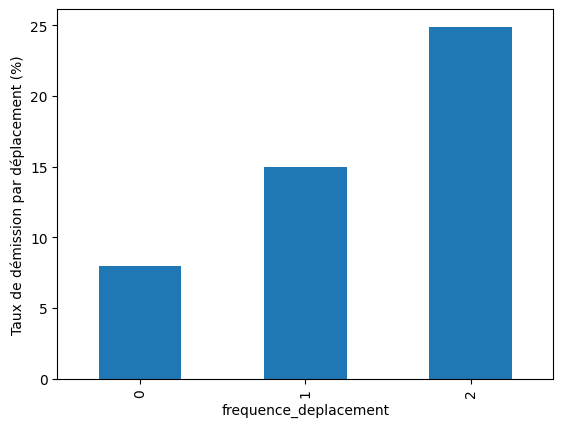

In [304]:
df.groupby("frequence_deplacement")["a_quitte_l_entreprise"].mean().mul(100).sort_values().plot(kind="bar", ylabel="Taux de démission par déplacement (%)")

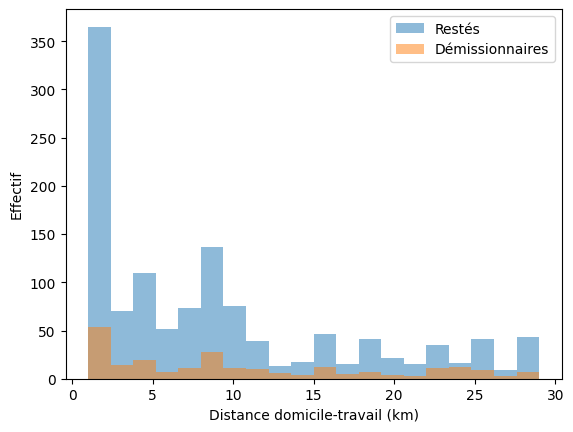

In [305]:
import matplotlib.pyplot as plt

df[df["a_quitte_l_entreprise"] == False]["distance_domicile_travail"].plot(
    kind="hist",
    bins=20,
    alpha=0.5,
    label="Restés"
)

df[df["a_quitte_l_entreprise"] == True]["distance_domicile_travail"].plot(
    kind="hist",
    bins=20,
    alpha=0.5,
    label="Démissionnaires"
)

plt.legend()
plt.xlabel("Distance domicile-travail (km)")
plt.ylabel("Effectif")
plt.show()

<Axes: xlabel='age'>

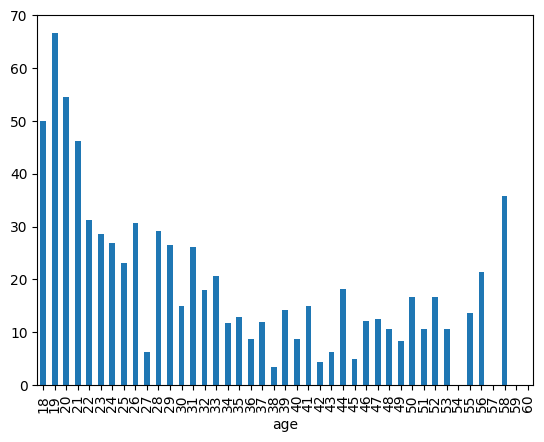

In [306]:
df.groupby("age")["a_quitte_l_entreprise"].mean().mul(100).plot(kind="bar")

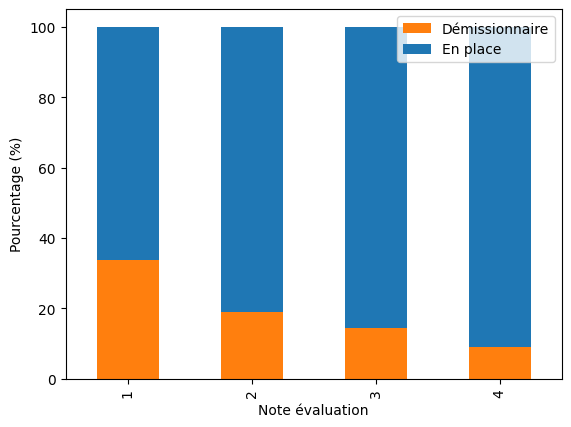

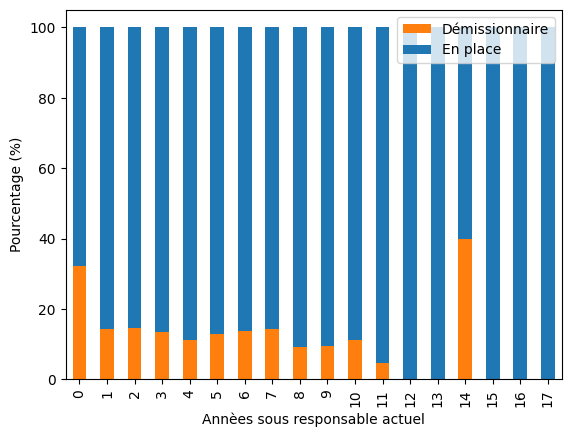

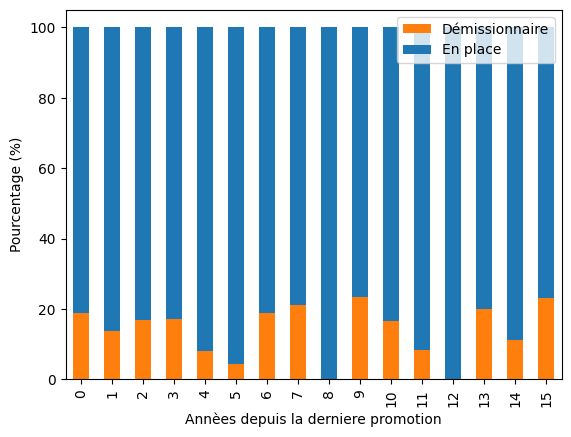

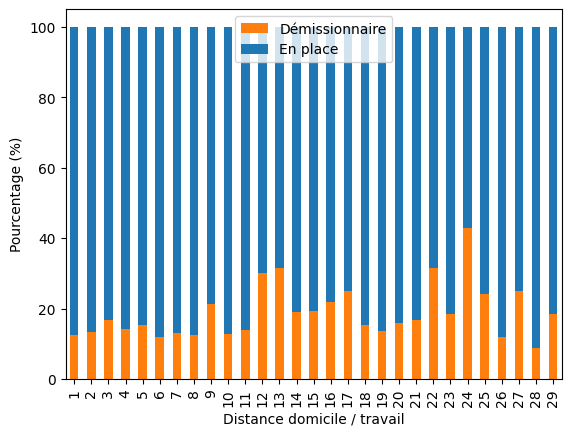

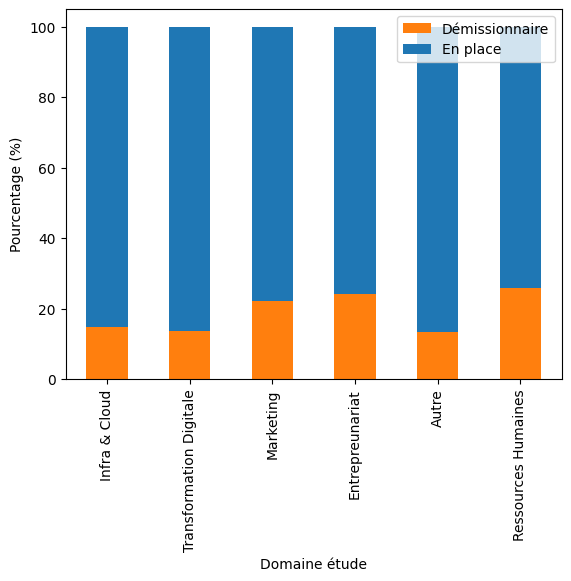

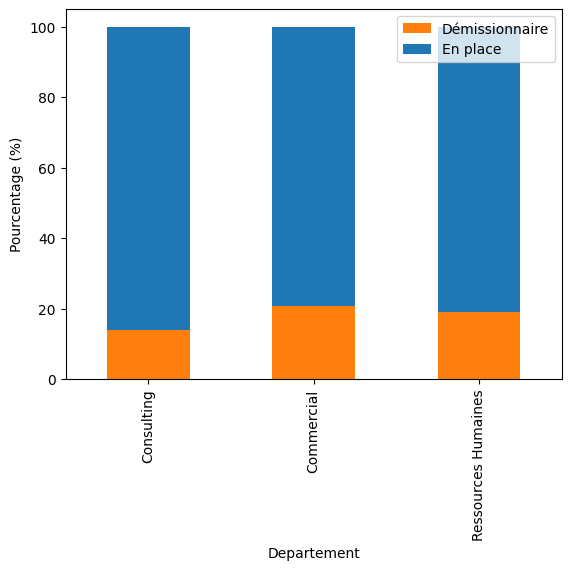

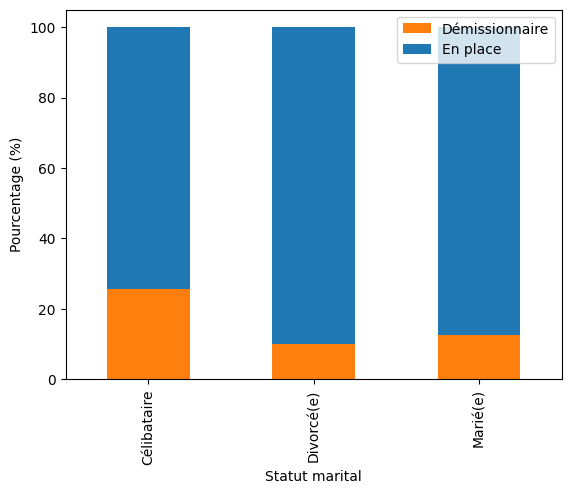

In [307]:
cols = [
    'note_evaluation_precedente',
    'annes_sous_responsable_actuel',
    'annees_depuis_la_derniere_promotion',
    'distance_domicile_travail',
    'domaine_etude',
    'departement',
    'statut_marital'
]

cols_label = [
    'Note évaluation',
    'Annèes sous responsable actuel',
    'Annèes depuis la derniere promotion',
    'Distance domicile / travail',
    'Domaine étude',
    'Departement',
    'Statut marital'
]

i = 0
for col in cols:

    count_dem = df_demission[col].value_counts()
    count_place = df_en_place[col].value_counts()

    # On combine les deux
    df_compare = pd.DataFrame({'Démissionnaire': count_dem, 'En place': count_place})

    # Convertir les effectifs en pourcentages
    df_perc = df_compare.div(df_compare.sum(axis=1), axis=0) * 100

    df_perc.plot(kind='bar', stacked=True, xlabel=cols_label[i], ylabel="Pourcentage (%)", color=['#FF7F0E', '#1F77B4'])

    i = i + 1

# Poste

<Axes: xlabel='poste', ylabel='Taux de démission par poste (%)'>

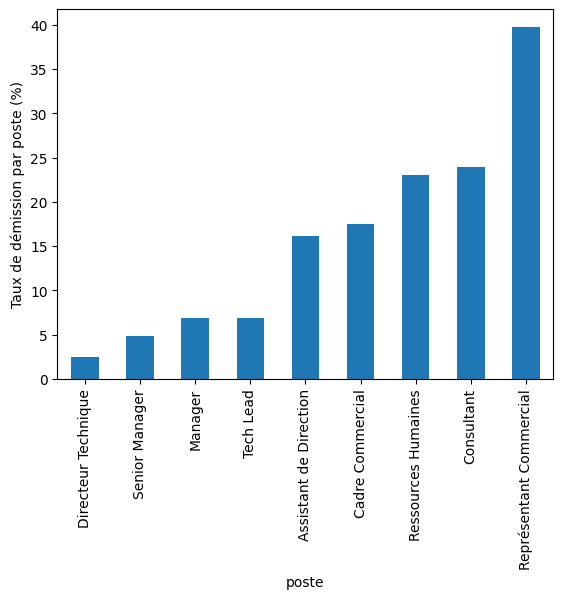

In [308]:
# affiche le taux de démission par poste
df.groupby("poste")["a_quitte_l_entreprise"].mean().mul(100).sort_values().plot(kind="bar", ylabel="Taux de démission par poste (%)")

<Axes: xlabel='Poste', ylabel='Pourcentage (%)'>

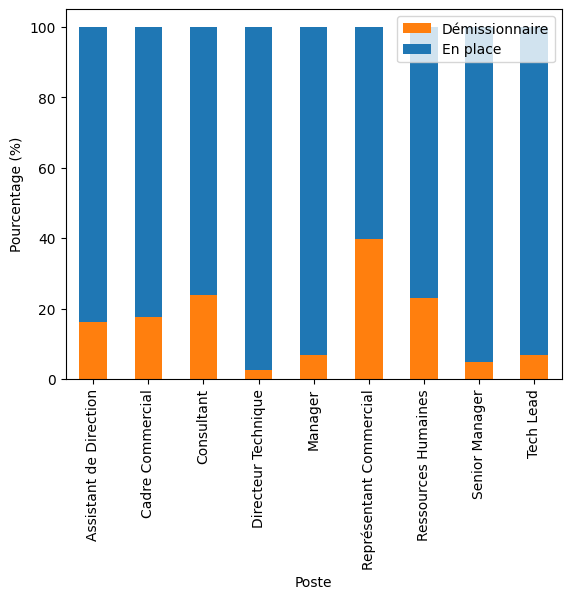

In [309]:
count_dem = df_demission['poste'].value_counts()
count_place = df_en_place['poste'].value_counts()

# On combine les deux
df_compare = pd.DataFrame({'Démissionnaire': count_dem, 'En place': count_place})

# Convertir les effectifs en pourcentages (par ligne / par poste)
df_perc = df_compare.div(df_compare.sum(axis=1), axis=0) * 100

df_perc.plot(kind='bar', stacked=True, xlabel="Poste", ylabel="Pourcentage (%)", color=['#FF7F0E', '#1F77B4'])

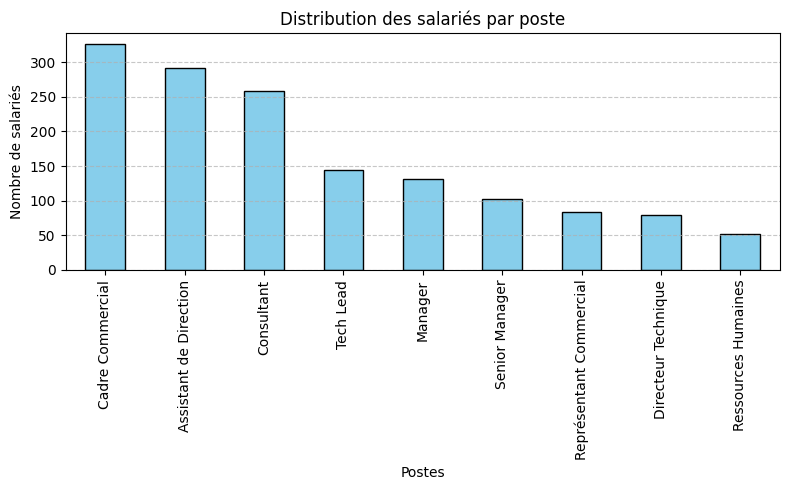

In [310]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Compter le nombre de salariés par poste et trier par ordre décroissant
distribution = df['poste'].value_counts()

# 2. Afficher le graphique
distribution.plot(kind='bar', figsize=(8, 5), color='skyblue', edgecolor='black')

plt.title('Distribution des salariés par poste')
plt.xlabel('Postes')
plt.ylabel('Nombre de salariés')
plt.xticks(rotation=90)  # Incline les noms pour éviter qu'ils se chevauchent
plt.grid(axis='y', linestyle='--', alpha=0.7) # Ajoute une grille de lecture
plt.tight_layout()
plt.show()

# Salaires / Postes

C:\Users\aceteam\AppData\Local\Temp\ipykernel_10436\3854705311.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='poste', y='revenu_mensuel', palette='Set2')


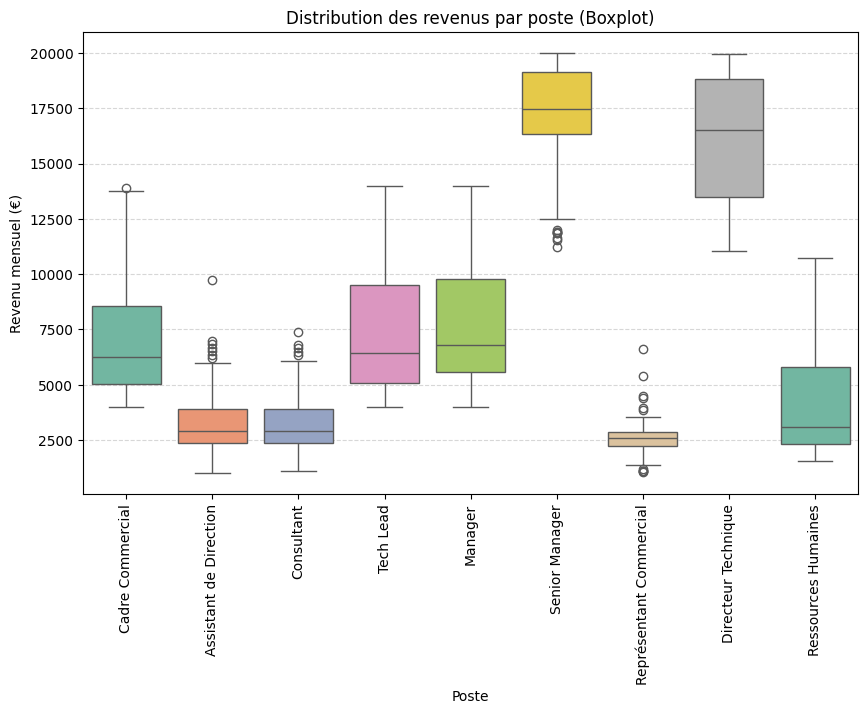

In [311]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Graphique avec Seaborn (très recommandé pour les boxplots)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='poste', y='revenu_mensuel', palette='Set2')

plt.title('Distribution des revenus par poste (Boxplot)')
plt.xlabel('Poste')
plt.xticks(rotation=90)  # Incline les noms pour éviter qu'ils se chevauchent
plt.ylabel('Revenu mensuel (€)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

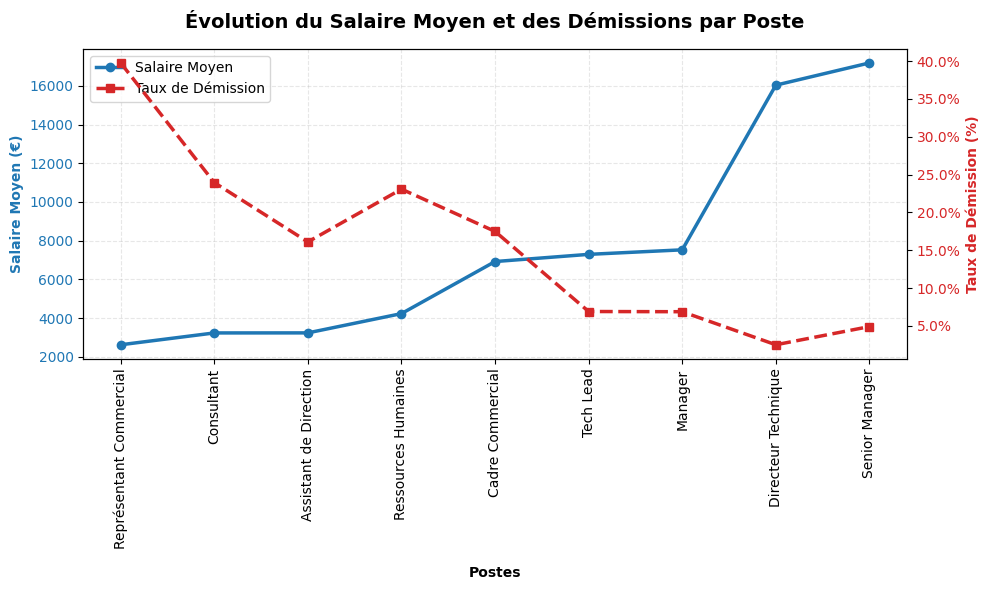

In [312]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 2. Agrégation des données par Poste
df_moyen = df.groupby('poste').agg(
    Salaire_Moyen=('revenu_mensuel', 'mean'),
    Taux_Demission=('a_quitte_l_entreprise', 'mean')
).reset_index()

# Optionnel : Trier par salaire pour que les courbes aient une progression logique
df_moyen = df_moyen.sort_values(by='Salaire_Moyen').reset_index(drop=True)

# 3. Création de la figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- PREMIÈRE COURBE : Salaire Moyen (Axe Y à gauche) ---
color_salaire = '#1f77b4' # Bleu
ax1.set_xlabel('Postes', fontweight='bold', labelpad=12)
plt.xticks(rotation=90)
ax1.set_ylabel('Salaire Moyen (€)', color=color_salaire, fontweight='bold')

# On trace la première courbe
line1 = ax1.plot(df_moyen['poste'], df_moyen['Salaire_Moyen'], 
                 color=color_salaire, marker='o', linewidth=2.5, label='Salaire Moyen')
ax1.tick_params(axis='y', labelcolor=color_salaire)
ax1.grid(True, linestyle='--', alpha=0.3) # Grille de fond

# --- DEUXIÈME COURBE : Démissions (Axe Y à droite) ---
ax2 = ax1.twinx() # Cloner l'axe X pour créer le deuxième axe Y
color_dem = '#d62728' # Rouge
ax2.set_ylabel('Taux de Démission (%)', color=color_dem, fontweight='bold')

# On trace la deuxième courbe
line2 = ax2.plot(df_moyen['poste'], df_moyen['Taux_Demission'], 
                 color=color_dem, marker='s', linewidth=2.5, linestyle='--', label='Taux de Démission')
ax2.tick_params(axis='y', labelcolor=color_dem)

# Formater l'axe de droite en pourcentage (0.2 devient 20%)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# --- LÉGENDE UNIQUE ---
# Comme on a deux axes, il faut combiner les légendes manuellement pour qu'elles s'affichent ensemble
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Évolution du Salaire Moyen et des Démissions par Poste', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

<Axes: xlabel='poste', ylabel='Taux de démission par poste (%)'>

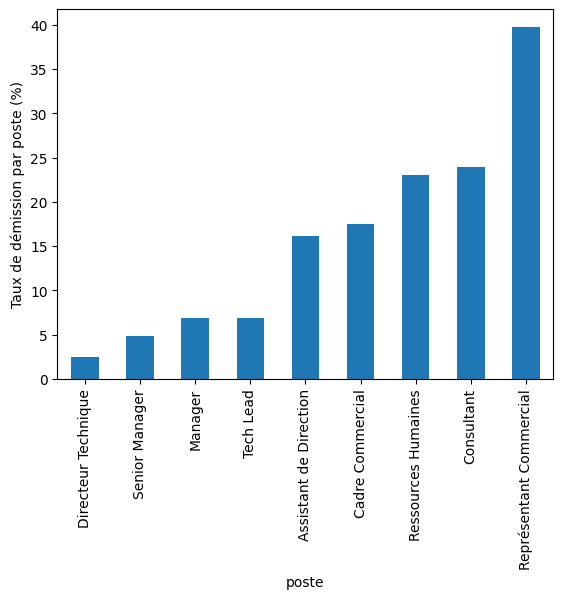

In [313]:
# affiche le taux de démission par poste
df.groupby("poste")["a_quitte_l_entreprise"].mean().mul(100).sort_values().plot(kind="bar", ylabel="Taux de démission par poste (%)")

<Axes: xlabel='poste', ylabel='Nombre de démissions'>

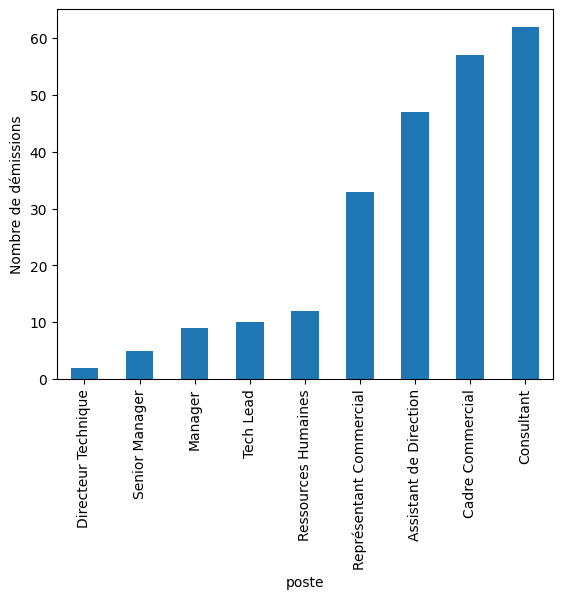

In [314]:
# répartition des démissions par poste
df_demission["poste"].value_counts(normalize=False).sort_values().plot(kind="bar", ylabel="Nombre de démissions")

<Axes: xlabel='departement'>

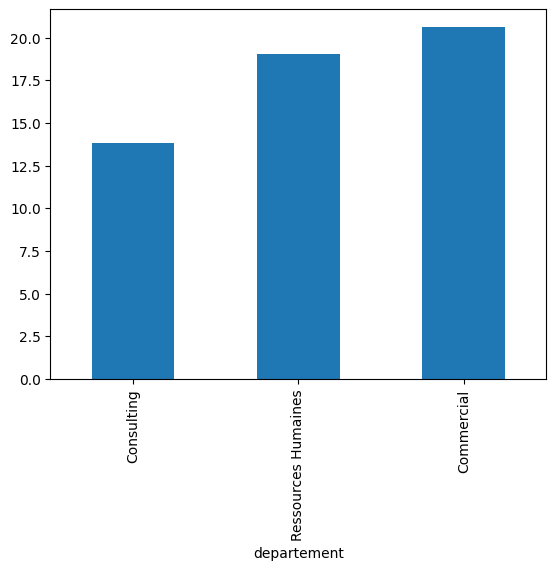

In [315]:
df.groupby("departement")["a_quitte_l_entreprise"].mean().mul(100).sort_values().plot(kind="bar")

<Axes: xlabel='statut_marital'>

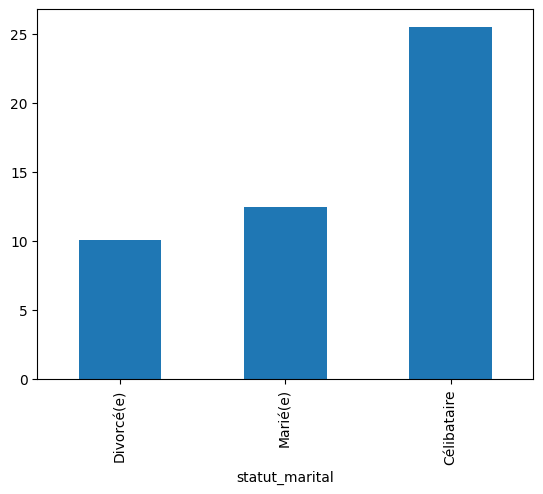

In [316]:
df.groupby("statut_marital")["a_quitte_l_entreprise"].mean().mul(100).sort_values().plot(kind="bar")

<Axes: xlabel='domaine_etude'>

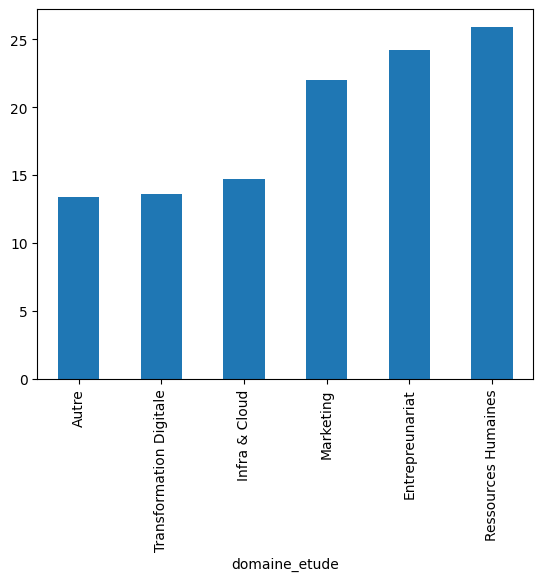

In [317]:
df.groupby("domaine_etude")["a_quitte_l_entreprise"].mean().mul(100).sort_values().plot(kind="bar")

In [318]:
df["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
False    0.838776
True     0.161224
Name: proportion, dtype: float64

In [319]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,bool
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,domaine_etude,object
6,frequence_deplacement,int64
7,annees_depuis_la_derniere_promotion,int64
8,annes_sous_responsable_actuel,int64
9,age,int64
